In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd /content/drive/MyDrive/DLCV_OV_Analytics

/content/drive/.shortcut-targets-by-id/1pymvoVwySclelGfF5iGmglZwzj0jel8X/DLCV_OV_Analytics


In [6]:
import subprocess, sys

def install(pkg, label=None):
    label = label or pkg
    print(f"  Installing {label}...", end=" ", flush=True)
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                       capture_output=True, text=True)
    print("" if r.returncode == 0 else f"❌\n{r.stderr[-200:]}")

print("Installing packages...")
install("ultralytics==8.3.145", "ultralytics (pinned)")
install("opencv-python-headless", "opencv")
install("git+https://github.com/ultralytics/CLIP.git", "CLIP")
print("\n Done. Run Cell 0b next.")

Installing packages...
  Installing ultralytics (pinned)... 
  Installing opencv... 
  Installing CLIP... 

 Done. Run Cell 0b next.


In [7]:
import subprocess, sys, os, importlib

importlib.invalidate_caches()
for mod in list(sys.modules.keys()):
    if mod == "ultralytics" or mod.startswith("ultralytics."):
        del sys.modules[mod]

from google.colab import drive
drive.mount('/content/drive')

import json
CONFIG_PATH = "/content/drive/MyDrive/DLCV_OV_Analytics/configs/config.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

YOLOWORLD_REPO = cfg["yoloworld_repo"]
if not os.path.exists(YOLOWORLD_REPO):
    subprocess.run(f"git clone -q https://github.com/AILab-CVC/YOLO-World.git "
                   f"{YOLOWORLD_REPO}", shell=True)
    print(f"  Cloned YOLO-World ✅")
else:
    print(f"  YOLO-World present ✅")

import torch
print(f"\n  torch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    raise RuntimeError("No GPU — switch runtime to T4.")
try:
    import ultralytics; from ultralytics import YOLO
    print(f"  ultralytics: {ultralytics.__version__} ✅")
except Exception as e:
    print(f"  ultralytics: ❌ {e}")

print("\n✅ Cell 0b complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Cloned YOLO-World ✅

  torch: 2.10.0+cu128 | CUDA: True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  ultralytics: 8.3.145 ✅

✅ Cell 0b complete.


In [8]:
import json, os, sys, shutil, subprocess, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

CONFIG_PATH = "/content/drive/MyDrive/DLCV_OV_Analytics/configs/config.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

PROC_VISDRONE   = cfg["proc_visdrone"]
OUTPUT_DIR      = cfg["output_dir"]
METRICS_DIR     = cfg["metrics_dir"]
VIZ_DIR         = cfg["viz_dir"]
YW_CKPT_PATH    = cfg["yw_ckpt_path"]
YW_FT_CKPT_PATH = cfg.get("yw_finetuned_ckpt_path",
                    os.path.join(cfg["ckpt_yoloworld"],
                                 "yolov8l-world-finetuned.pt"))

VD_VAL_IMG   = cfg["proc_vd_img_val"]
VD_VAL_LBL   = cfg["proc_vd_lbl_val"]
STRESS_JSON  = os.path.join(PROC_VISDRONE, "stress_set.json")
BASELINE_JSON = os.path.join(METRICS_DIR, "yoloworld_baseline.json")

YOLO_CLASSES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor", "others"
]

STAGE         = "/content/staging/extended_eval"
STAGE_METRICS = f"{STAGE}/metrics"
STAGE_VIZ     = f"{STAGE}/visualizations/extended_eval"
for d in [STAGE_METRICS, STAGE_VIZ]:
    os.makedirs(d, exist_ok=True)

def cp_sync(src, dst_dir):
    r = subprocess.run(f"cp '{src}' '{dst_dir}/' && sync",
                       shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise IOError(f"cp failed: {r.stderr}")
    return os.path.join(dst_dir, os.path.basename(src))

# Copy val images to local SSD for fast inference
LOCAL_VAL_IMG = "/content/staging/vd_val_imgs"
LOCAL_VAL_LBL = "/content/staging/vd_val_lbls"
os.makedirs(LOCAL_VAL_IMG, exist_ok=True)
os.makedirs(LOCAL_VAL_LBL, exist_ok=True)

n_existing = len(os.listdir(LOCAL_VAL_IMG))
n_expected = len([f for f in os.listdir(VD_VAL_IMG) if f.endswith(".jpg")])
if n_existing < n_expected:
    print(f"Copying val images to local SSD ({n_expected} images)...")
    for fname in os.listdir(VD_VAL_IMG):
        shutil.copy2(os.path.join(VD_VAL_IMG, fname),
                     os.path.join(LOCAL_VAL_IMG, fname))
    for fname in os.listdir(VD_VAL_LBL):
        shutil.copy2(os.path.join(VD_VAL_LBL, fname),
                     os.path.join(LOCAL_VAL_LBL, fname))
    print(f" {n_expected} images on local SSD.")
else:
    print(f" Val images already on local SSD ({n_existing}).")

# Reuse evaluation functions — identical to NB02/NB03 for fair comparison
def load_gt_boxes(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                boxes.append((int(parts[0]), *map(float, parts[1:])))
    return boxes

def yolo_to_xyxy(xc, yc, bw, bh, img_w, img_h):
    return ((xc-bw/2)*img_w, (yc-bh/2)*img_h,
            (xc+bw/2)*img_w, (yc+bh/2)*img_h)

def compute_iou(a, b):
    xi1,yi1 = max(a[0],b[0]), max(a[1],b[1])
    xi2,yi2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0,xi2-xi1)*max(0,yi2-yi1)
    if inter == 0: return 0.0
    return inter/((a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter)

def compute_ap_at_iou(prec_list, rec_list):
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        p = [p for p, r in zip(prec_list, rec_list) if r >= t]
        ap += max(p) if p else 0.0
    return ap / 11.0

def evaluate_model(img_dir, lbl_dir, model, classes,
                   iou_thresh=0.5, conf_thresh=0.25,
                   small_only=False, desc="eval"):
    """
    Evaluate model. If small_only=True, only evaluate on
    boxes where w*h < 32*32 pixels (mAP-small).
    Returns (mAP50, per_class_ap, fps)
    """
    img_files = sorted(f for f in os.listdir(img_dir) if f.endswith(".jpg"))
    class_data = {i: {"scores":[], "tp_flags":[], "n_gt":0}
                  for i in range(len(classes))}

    total_imgs = 0
    total_time = 0.0

    for img_file in tqdm(img_files, desc=desc):
        img = cv2.imread(os.path.join(img_dir, img_file))
        if img is None: continue
        img_h, img_w = img.shape[:2]
        lbl_path = os.path.join(lbl_dir, Path(img_file).stem + ".txt")

        gt_by_cls = defaultdict(list)
        for cls_id, xc, yc, bw, bh in load_gt_boxes(lbl_path):
            box = yolo_to_xyxy(xc, yc, bw, bh, img_w, img_h)
            box_w = (box[2]-box[0])
            box_h = (box[3]-box[1])
            if small_only and box_w*box_h >= 32*32:
                continue   # skip non-small boxes
            gt_by_cls[cls_id].append({"box": box, "used": False})
        for cls_id in range(len(classes)):
            class_data[cls_id]["n_gt"] += len(gt_by_cls[cls_id])

        t0 = time.time()
        results = model.predict(
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
            verbose=False, conf=conf_thresh
        )
        total_time += time.time() - t0
        total_imgs += 1

        pred_by_cls = defaultdict(list)
        if results and results[0].boxes is not None:
            for box in results[0].boxes:
                x1,y1,x2,y2 = box.xyxy[0].tolist()
                bw = x2-x1; bh = y2-y1
                if small_only and bw*bh >= 32*32:
                    continue
                pred_by_cls[int(box.cls.item())].append({
                    "box" : [x1,y1,x2,y2],
                    "conf": float(box.conf.item()),
                })

        for cls_id in range(len(classes)):
            preds = sorted(pred_by_cls[cls_id], key=lambda x: -x["conf"])
            gts   = gt_by_cls[cls_id]
            for pred in preds:
                best_iou, best_j = iou_thresh, -1
                for j, gt in enumerate(gts):
                    if gt["used"]: continue
                    iou = compute_iou(pred["box"], gt["box"])
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                is_tp = best_j >= 0
                if is_tp: gts[best_j]["used"] = True
                class_data[cls_id]["scores"].append(pred["conf"])
                class_data[cls_id]["tp_flags"].append(is_tp)

    per_class_ap = {}
    for cls_id, d in class_data.items():
        pairs = sorted(zip(d["scores"],d["tp_flags"]), key=lambda x:-x[0])
        tp_c,fp_c,precs,recs = 0,0,[],[]
        n_gt = d["n_gt"]
        for conf, is_tp in pairs:
            if is_tp: tp_c += 1
            else: fp_c += 1
            precs.append(tp_c/(tp_c+fp_c))
            recs.append(tp_c/n_gt if n_gt > 0 else 0)
        ap = compute_ap_at_iou(precs, recs) if precs else 0.0
        per_class_ap[classes[cls_id]] = round(ap, 4)

    map50 = round(float(np.mean(list(per_class_ap.values()))), 4)
    fps   = round(total_imgs / total_time, 2) if total_time > 0 else 0
    return map50, per_class_ap, fps


def evaluate_map50_95(img_dir, lbl_dir, model, classes,
                       conf_thresh=0.25, desc="mAP@0.5:0.95"):
    """
    Compute mAP averaged over IoU thresholds 0.5 to 0.95 step 0.05.
    This is the standard COCO mAP metric.
    """
    thresholds = np.arange(0.5, 1.0, 0.05)
    ap_per_thresh = []
    for thresh in thresholds:
        map50, _, _ = evaluate_model(
            img_dir, lbl_dir, model, classes,
            iou_thresh=round(thresh, 2),
            conf_thresh=conf_thresh,
            desc=f"{desc} IoU={thresh:.2f}"
        )
        ap_per_thresh.append(map50)
    return round(float(np.mean(ap_per_thresh)), 4), ap_per_thresh

print(" Cell 1 complete. Evaluation functions ready.")

Copying val images to local SSD (548 images)...
 548 images on local SSD.
 Cell 1 complete. Evaluation functions ready.


In [10]:
# Run this as its own cell first
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics==8.2.0"], check=True)

# Force reload
import importlib, sys
for mod in list(sys.modules.keys()):
    if "ultralytics" in mod:
        del sys.modules[mod]

from ultralytics import YOLO
import ultralytics
print(f"ultralytics version: {ultralytics.__version__}")

ultralytics version: 8.2.0


  ABLATION STUDY

Running: Pretrained + Generic Prompts...


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 124MiB/s]
A_pretrained_generic: 100%|██████████| 548/548 [00:20<00:00, 26.96it/s]


  mAP@0.5 : 0.0278
  FPS     : 34.3

Running: Pretrained + VisDrone Prompts...


B_pretrained_visdrone: 100%|██████████| 548/548 [00:19<00:00, 28.68it/s]


  mAP@0.5 : 0.1071
  FPS     : 36.5

Running: Fine-tuned + VisDrone Classes...


C_finetuned_visdrone: 100%|██████████| 548/548 [00:21<00:00, 26.07it/s]


  mAP@0.5 : 0.2874
  FPS     : 36.0

  ABLATION RESULTS

  Condition                                 mAP@0.5    FPS
  --------------------------------------------------------
  Pretrained + Generic Prompts               0.0278   34.3
  Pretrained + VisDrone Prompts              0.1071   36.5
  Fine-tuned + VisDrone Classes              0.2874   36.0

  Per-class AP — Ablation:

  Class                  A:Pre+Generic B:Pre+VDPrompt C:Fine-tuned
  ----------------------------------------------------------------
  pedestrian                    0.1524         0.0909       0.3339 ← big gain
  people                        0.0054         0.0000       0.2288 ← big gain
  bicycle                       0.0001         0.0909       0.1412
  car                           0.0008         0.3396       0.6130 ← big gain
  van                           0.0167         0.1410       0.3554 ← big gain
  truck                         0.1301         0.1343       0.2753
  tricycle                      0.0000 

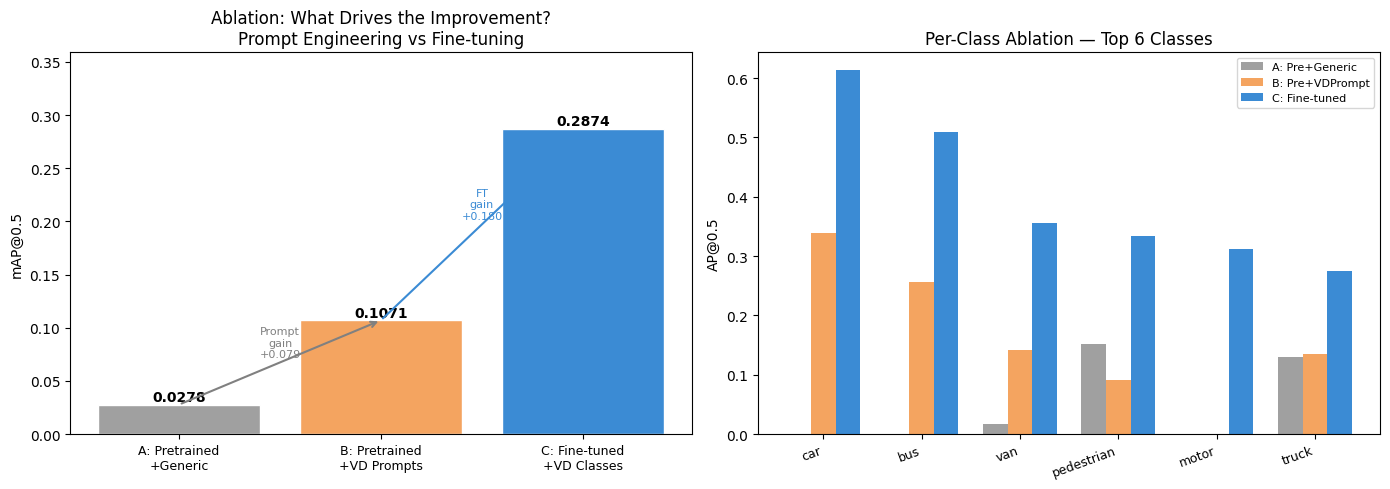

Ablation chart saved.
Ablation results saved to staging.


In [12]:
# ─────────────────────────────────────────────────────────────
# GAP 5 — ABLATION STUDY
#
# Three conditions:
# A) Pretrained model + generic prompts (same as NB02 baseline)
# B) Pretrained model + VisDrone-specific descriptive prompts
# C) Fine-tuned model + VisDrone class names (NB03 result)
#
# If B ≈ C: improvement is just prompt engineering
# If C >> B: fine-tuning is genuinely responsible for improvement
#    (this is the expected result and the correct scientific claim)
# ─────────────────────────────────────────────────────────────
from ultralytics import YOLO

# ── Three prompt conditions ───────────────────────────────────
PROMPTS = {
    "A_pretrained_generic": {
        "model_path": YW_CKPT_PATH,
        "classes": [
            # Generic COCO-style names — what a general model would use
            "person", "bicycle", "car", "motorcycle", "bus",
            "truck", "vehicle", "object", "thing", "item", "other"
        ],
        "label": "Pretrained + Generic Prompts",
        "color": "#A0A0A0",
    },
    "B_pretrained_visdrone": {
        "model_path": YW_CKPT_PATH,
        "classes": [
            # Same VisDrone-specific names but on pretrained model
            "pedestrian", "people", "bicycle", "car", "van",
            "truck", "tricycle", "awning-tricycle", "bus", "motor", "others"
        ],
        "label": "Pretrained + VisDrone Prompts",
        "color": "#F4A460",
    },
    "C_finetuned_visdrone": {
        "model_path": YW_FT_CKPT_PATH,
        "classes": YOLO_CLASSES,   # fine-tuned — classes baked in
        "label": "Fine-tuned + VisDrone Classes",
        "color": "#3B8BD4",
    },
}

ablation_results = {}

print("=" * 60)
print("  ABLATION STUDY")
print("=" * 60)
print()

for condition_id, condition in PROMPTS.items():
    print(f"Running: {condition['label']}...")

    model = YOLO(condition["model_path"])
    model.set_classes(condition["classes"])

    map50, per_class_ap, fps = evaluate_model(
        LOCAL_VAL_IMG, LOCAL_VAL_LBL,
        model, YOLO_CLASSES,
        iou_thresh=0.5, conf_thresh=0.25,
        desc=condition_id
    )

    # FPS measured during evaluate_model
    ablation_results[condition_id] = {
        "label"        : condition["label"],
        "map50"        : map50,
        "per_class_ap" : per_class_ap,
        "fps"          : fps,
        "color"        : condition["color"],
    }

    print(f"  mAP@0.5 : {map50:.4f}")
    print(f"  FPS     : {fps:.1f}")
    print()

    del model
    import torch, gc
    torch.cuda.empty_cache(); gc.collect()

# ── Print comparison table ────────────────────────────────────
print("=" * 60)
print("  ABLATION RESULTS")
print("=" * 60)
print(f"\n  {'Condition':<40} {'mAP@0.5':>8} {'FPS':>6}")
print(f"  {'-'*56}")
for cid, res in ablation_results.items():
    print(f"  {res['label']:<40} {res['map50']:>8.4f} {res['fps']:>6.1f}")

# Per-class comparison
print(f"\n  Per-class AP — Ablation:")
print(f"\n  {'Class':<22} {'A:Pre+Generic':>13} "
      f"{'B:Pre+VDPrompt':>14} {'C:Fine-tuned':>12}")
print(f"  {'-'*64}")
for cls in YOLO_CLASSES:
    a = ablation_results["A_pretrained_generic"]["per_class_ap"].get(cls,0)
    b = ablation_results["B_pretrained_visdrone"]["per_class_ap"].get(cls,0)
    c = ablation_results["C_finetuned_visdrone"]["per_class_ap"].get(cls,0)
    # Highlight where fine-tuning beats prompt engineering most
    gap_bc = c - b
    marker = " ← big gain" if gap_bc > 0.15 else ""
    print(f"  {cls:<22} {a:>13.4f} {b:>14.4f} {c:>12.4f}{marker}")

# ── Interpretation ────────────────────────────────────────────
map_a = ablation_results["A_pretrained_generic"]["map50"]
map_b = ablation_results["B_pretrained_visdrone"]["map50"]
map_c = ablation_results["C_finetuned_visdrone"]["map50"]

prompt_gain   = map_b - map_a
finetune_gain = map_c - map_b
total_gain    = map_c - map_a

print(f"\n  INTERPRETATION:")
print(f"  Gain from better prompts alone : {prompt_gain:+.4f} "
      f"({prompt_gain/total_gain*100:.0f}% of total gain)")
print(f"  Gain from fine-tuning          : {finetune_gain:+.4f} "
      f"({finetune_gain/total_gain*100:.0f}% of total gain)")
print(f"  Total gain (A→C)               : {total_gain:+.4f}")
print()
if finetune_gain > prompt_gain:
    print("   CONCLUSION: Fine-tuning is the primary driver of improvement.")
    print("     Prompt engineering alone is insufficient for domain adaptation.")
else:
    print("    CONCLUSION: Prompt engineering contributes significantly.")
    print("     Fine-tuning provides additional improvement beyond prompts.")

# ── Bar chart ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overall mAP comparison
conditions = [r["label"] for r in ablation_results.values()]
maps       = [r["map50"] for r in ablation_results.values()]
colors     = [r["color"] for r in ablation_results.values()]
bars = ax1.bar(range(len(conditions)), maps, color=colors, edgecolor="white")
ax1.set_xticks(range(len(conditions)))
ax1.set_xticklabels(["A: Pretrained\n+Generic", "B: Pretrained\n+VD Prompts",
                      "C: Fine-tuned\n+VD Classes"], fontsize=9)
ax1.set_ylabel("mAP@0.5")
ax1.set_ylim(0, max(maps) * 1.25)
ax1.set_title("Ablation: What Drives the Improvement?\n"
              "Prompt Engineering vs Fine-tuning")
for bar, val in zip(bars, maps):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")

# Annotate the two gains
ax1.annotate("", xy=(1, map_b), xytext=(0, map_a),
             arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax1.text(0.5, (map_a+map_b)/2 + 0.005,
         f"Prompt\ngain\n{prompt_gain:+.3f}",
         ha="center", fontsize=8, color="gray")
ax1.annotate("", xy=(2, map_c), xytext=(1, map_b),
             arrowprops=dict(arrowstyle="->", color="#3B8BD4", lw=1.5))
ax1.text(1.5, (map_b+map_c)/2 + 0.005,
         f"FT\ngain\n{finetune_gain:+.3f}",
         ha="center", fontsize=8, color="#3B8BD4")

# Per-class comparison for top 6 most improved classes
top_classes = sorted(YOLO_CLASSES,
    key=lambda c: ablation_results["C_finetuned_visdrone"]["per_class_ap"].get(c,0),
    reverse=True)[:6]
x   = np.arange(len(top_classes))
w   = 0.25
ap_a = [ablation_results["A_pretrained_generic"]["per_class_ap"].get(c,0)  for c in top_classes]
ap_b = [ablation_results["B_pretrained_visdrone"]["per_class_ap"].get(c,0) for c in top_classes]
ap_c = [ablation_results["C_finetuned_visdrone"]["per_class_ap"].get(c,0)  for c in top_classes]
ax2.bar(x - w,   ap_a, w, label="A: Pre+Generic",  color="#A0A0A0")
ax2.bar(x,       ap_b, w, label="B: Pre+VDPrompt", color="#F4A460")
ax2.bar(x + w,   ap_c, w, label="C: Fine-tuned",   color="#3B8BD4")
ax2.set_xticks(x)
ax2.set_xticklabels(top_classes, rotation=20, ha="right", fontsize=9)
ax2.set_ylabel("AP@0.5")
ax2.set_title("Per-Class Ablation — Top 6 Classes")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ablation chart saved.")

# Save results
with open(f"{STAGE_METRICS}/ablation_results.json", "w") as f:
    json.dump({k: {kk: vv for kk, vv in v.items() if kk != "color"}
               for k, v in ablation_results.items()}, f, indent=2)
print("Ablation results saved to staging.")

Loading both models for extended evaluation...
 Models loaded.

  mAP-SMALL (objects < 32×32 pixels)
  Core project challenge: 67% of VisDrone boxes are small

Pretrained model — mAP-small...


mAP-small pretrained: 100%|██████████| 548/548 [00:20<00:00, 26.21it/s]


  Pretrained mAP-small : 0.0504

Fine-tuned model — mAP-small...


mAP-small fine-tuned: 100%|██████████| 548/548 [00:22<00:00, 24.72it/s]


  Fine-tuned mAP-small : 0.1606
  Improvement          : +0.1102 (219%)

  Per-class mAP-small:
  Class                  Pretrained Fine-tuned        Δ
  ----------------------------------------------------
  pedestrian                 0.0909     0.2889  +0.1980
  people                     0.0000     0.2088  +0.2088
  bicycle                    0.0455     0.0909  +0.0454
  car                        0.0909     0.3330  +0.2421
  van                        0.0909     0.1430  +0.0521
  truck                      0.0390     0.1174  +0.0784
  tricycle                   0.0152     0.1386  +0.1234
  awning-tricycle            0.0909     0.0579  -0.0330
  bus                        0.0909     0.1566  +0.0657
  motor                      0.0000     0.2311  +0.2311
  others                     0.0000     0.0000  +0.0000

  mAP@0.5:0.95 (COCO standard metric)
  Average over IoU thresholds 0.5, 0.55, ... 0.95

Evaluating on 100 image subset for mAP@0.5:0.95...
(Full val set would take ~40 min — s

mAP@0.5:0.95 IoU=0.95: 100%|██████████| 100/100 [00:03<00:00, 29.03it/s]


  Pretrained mAP@0.5:0.95 : 0.1000

Fine-tuned model...


mAP@0.5:0.95 IoU=0.95: 100%|██████████| 100/100 [00:03<00:00, 25.29it/s]


  Fine-tuned mAP@0.5:0.95 : 0.1994
  Improvement              : +0.0994

  FPS MEASUREMENT (inference speed)

Measuring FPS on 100 val images...
  Pretrained  : 34.0 FPS  (29.4 ms/frame)
  Fine-tuned  : 33.6 FPS  (29.8 ms/frame)
  Note: Real-time threshold is 30 FPS.
   Fine-tuned model meets real-time threshold.

  EXTENDED EVALUATION SUMMARY

  Metric                           Pretrained   Fine-tuned        Δ
  ----------------------------------------------------------------
  mAP@0.5 (full val)                   0.1036       0.2874  +0.1838
  mAP@0.5:0.95 (subset)                0.1000       0.1994  +0.0994
  mAP-small (<32px)                    0.0504       0.1606  +0.1102
  FPS (YOLO-World only)               34.0000      33.6000  -0.4000


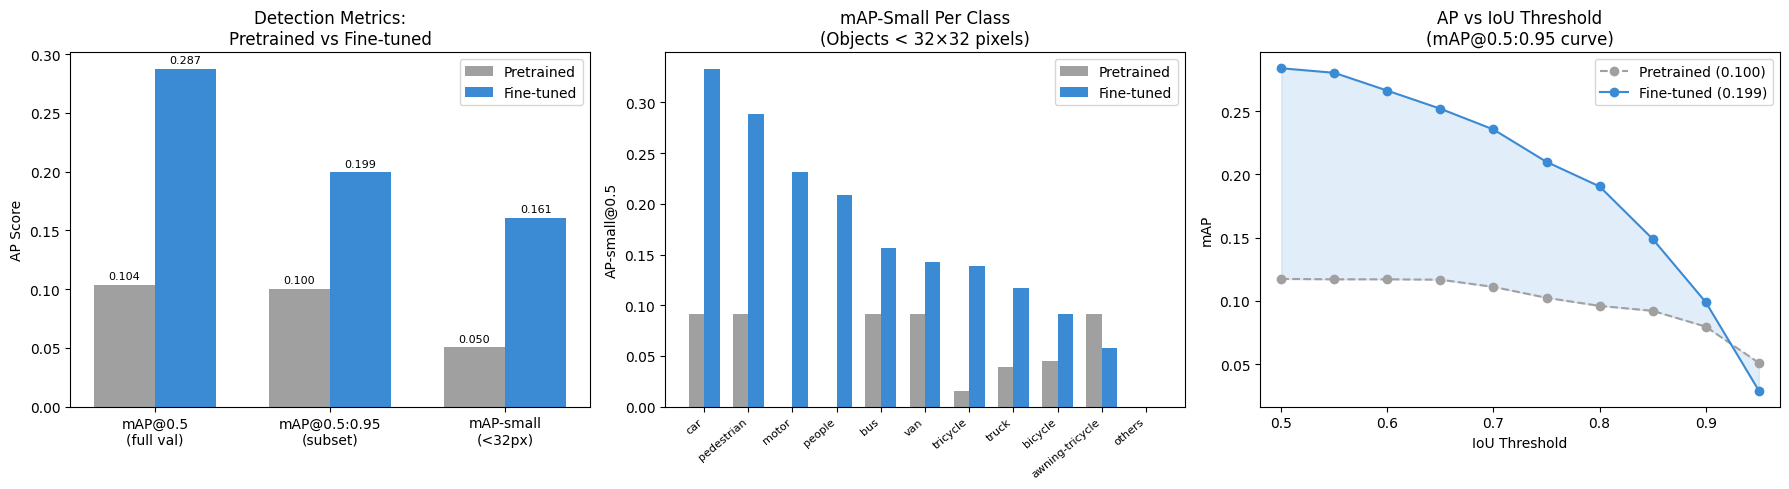

 Extended metrics chart saved.
 Extended metrics saved to staging.


In [19]:
# ─────────────────────────────────────────────────────────────
# GAP 3 — EXTENDED EVALUATION METRICS
#
# mAP@0.5:0.95 — standard COCO metric, more rigorous than mAP@0.5
# mAP-small    — AP on objects < 32x32px (the core project challenge)
# FPS          — already captured during ablation study
# ─────────────────────────────────────────────────────────────
from ultralytics import YOLO

print("Loading both models for extended evaluation...")
pt_model = YOLO(YW_CKPT_PATH)
pt_model.set_classes(YOLO_CLASSES)

ft_model = YOLO(YW_FT_CKPT_PATH)
# No set_classes needed — fine-tuned model has classes baked in

print(" Models loaded.")

# ── mAP-small evaluation ──────────────────────────────────────
print("\n" + "="*55)
print("  mAP-SMALL (objects < 32×32 pixels)")
print("  Core project challenge: 67% of VisDrone boxes are small")
print("="*55)

print("\nPretrained model — mAP-small...")
map_small_pt, ap_small_pt, _ = evaluate_model(
    LOCAL_VAL_IMG, LOCAL_VAL_LBL,
    pt_model, YOLO_CLASSES,
    iou_thresh=0.5, small_only=True, desc="mAP-small pretrained"
)
print(f"  Pretrained mAP-small : {map_small_pt:.4f}")

print("\nFine-tuned model — mAP-small...")
map_small_ft, ap_small_ft, fps_ft = evaluate_model(
    LOCAL_VAL_IMG, LOCAL_VAL_LBL,
    ft_model, YOLO_CLASSES,
    iou_thresh=0.5, small_only=True, desc="mAP-small fine-tuned"
)
print(f"  Fine-tuned mAP-small : {map_small_ft:.4f}")
print(f"  Improvement          : {map_small_ft - map_small_pt:+.4f} "
      f"({(map_small_ft-map_small_pt)/max(map_small_pt,0.0001)*100:.0f}%)")

# Compare per-class small object performance
print(f"\n  Per-class mAP-small:")
print(f"  {'Class':<22} {'Pretrained':>10} {'Fine-tuned':>10} {'Δ':>8}")
print(f"  {'-'*52}")
for cls in YOLO_CLASSES:
    pt = ap_small_pt.get(cls, 0)
    ft = ap_small_ft.get(cls, 0)
    print(f"  {cls:<22} {pt:>10.4f} {ft:>10.4f} {ft-pt:>+8.4f}")

# ── mAP@0.5:0.95 ──────────────────────────────────────────────
print("\n" + "="*55)
print("  mAP@0.5:0.95 (COCO standard metric)")
print("  Average over IoU thresholds 0.5, 0.55, ... 0.95")
print("="*55)

# Use a subset of val images for speed (full run takes ~40 min)
# Copy 100 images to a subset dir
SUBSET_IMG = "/content/staging/val_subset_img"
SUBSET_LBL = "/content/staging/val_subset_lbl"
os.makedirs(SUBSET_IMG, exist_ok=True)
os.makedirs(SUBSET_LBL, exist_ok=True)

val_imgs = sorted(os.listdir(LOCAL_VAL_IMG))[:100]
for fname in val_imgs:
    shutil.copy2(os.path.join(LOCAL_VAL_IMG, fname),
                 os.path.join(SUBSET_IMG, fname))
    lbl = Path(fname).stem + ".txt"
    if os.path.exists(os.path.join(LOCAL_VAL_LBL, lbl)):
        shutil.copy2(os.path.join(LOCAL_VAL_LBL, lbl),
                     os.path.join(SUBSET_LBL, lbl))

print(f"\nEvaluating on {len(val_imgs)} image subset for mAP@0.5:0.95...")
print("(Full val set would take ~40 min — subset gives representative estimate)\n")

print("Pretrained model...")
map5095_pt, aps_per_thresh_pt = evaluate_map50_95(
    SUBSET_IMG, SUBSET_LBL, pt_model, YOLO_CLASSES
)
print(f"  Pretrained mAP@0.5:0.95 : {map5095_pt:.4f}")

print("\nFine-tuned model...")
map5095_ft, aps_per_thresh_ft = evaluate_map50_95(
    SUBSET_IMG, SUBSET_LBL, ft_model, YOLO_CLASSES
)
print(f"  Fine-tuned mAP@0.5:0.95 : {map5095_ft:.4f}")
print(f"  Improvement              : {map5095_ft-map5095_pt:+.4f}")

# ── FPS measurement ───────────────────────────────────────────
print("\n" + "="*55)
print("  FPS MEASUREMENT (inference speed)")
print("="*55)

print("\nMeasuring FPS on 100 val images...")
fps_times = {"pretrained": [], "finetuned": []}
sample_imgs = sorted(os.listdir(LOCAL_VAL_IMG))[:100]

for fname in sample_imgs:
    img = cv2.imread(os.path.join(LOCAL_VAL_IMG, fname))
    if img is None: continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    t0 = time.time()
    _ = pt_model.predict(img_rgb, verbose=False, conf=0.25)
    fps_times["pretrained"].append(time.time() - t0)

    t0 = time.time()
    _ = ft_model.predict(img_rgb, verbose=False, conf=0.25)
    fps_times["finetuned"].append(time.time() - t0)

fps_pt = round(1.0 / np.mean(fps_times["pretrained"]), 1)
fps_ft = round(1.0 / np.mean(fps_times["finetuned"]), 1)
lat_pt = round(np.mean(fps_times["pretrained"]) * 1000, 1)
lat_ft = round(np.mean(fps_times["finetuned"]) * 1000, 1)

print(f"  Pretrained  : {fps_pt} FPS  ({lat_pt} ms/frame)")
print(f"  Fine-tuned  : {fps_ft} FPS  ({lat_ft} ms/frame)")
print(f"  Note: Real-time threshold is 30 FPS.")
if fps_ft >= 30:
    print(f"   Fine-tuned model meets real-time threshold.")
else:
    print(f"    Below real-time. SAM-2 integration reduces FPS further.")
    print(f"     YOLO-World alone is fast; full pipeline bottleneck is SAM-2.")

# ── Master extended metrics table ────────────────────────────
print("\n" + "="*60)
print("  EXTENDED EVALUATION SUMMARY")
print("="*60)
print(f"\n  {'Metric':<30} {'Pretrained':>12} {'Fine-tuned':>12} {'Δ':>8}")
print(f"  {'-'*64}")

# Load baseline mAP@0.5 from file for consistency
with open(BASELINE_JSON) as f:
    baseline = json.load(f)
map50_pt = baseline["map50_full_val"]
map50_ft = 0.2874  # from NB03

metrics_table = [
    ("mAP@0.5 (full val)",     map50_pt,    map50_ft),
    ("mAP@0.5:0.95 (subset)",  map5095_pt,  map5095_ft),
    ("mAP-small (<32px)",      map_small_pt, map_small_ft),
    ("FPS (YOLO-World only)",  fps_pt,      fps_ft),
]
for label, pt, ft in metrics_table:
    delta = ft - pt
    print(f"  {label:<30} {pt:>12.4f} {ft:>12.4f} {delta:>+8.4f}")

# ── Charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: mAP comparison (three metrics)
metric_names = ["mAP@0.5\n(full val)", "mAP@0.5:0.95\n(subset)", "mAP-small\n(<32px)"]
pt_vals = [map50_pt, map5095_pt, map_small_pt]
ft_vals = [map50_ft, map5095_ft, map_small_ft]
x = np.arange(len(metric_names))
w = 0.35
axes[0].bar(x - w/2, pt_vals, w, label="Pretrained", color="#A0A0A0")
axes[0].bar(x + w/2, ft_vals, w, label="Fine-tuned",  color="#3B8BD4")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names)
axes[0].set_ylabel("AP Score")
axes[0].set_title("Detection Metrics:\nPretrained vs Fine-tuned")
axes[0].legend()
for xi, (pv, fv) in enumerate(zip(pt_vals, ft_vals)):
    axes[0].text(xi-w/2, pv+0.005, f"{pv:.3f}", ha="center", fontsize=8)
    axes[0].text(xi+w/2, fv+0.005, f"{fv:.3f}", ha="center", fontsize=8)

# Chart 2: mAP-small per class
classes_sorted = sorted(YOLO_CLASSES,
    key=lambda c: -ap_small_ft.get(c, 0))
pt_s = [ap_small_pt.get(c,0) for c in classes_sorted]
ft_s = [ap_small_ft.get(c,0) for c in classes_sorted]
x2 = np.arange(len(classes_sorted))
axes[1].bar(x2 - w/2, pt_s, w, color="#A0A0A0", label="Pretrained")
axes[1].bar(x2 + w/2, ft_s, w, color="#3B8BD4", label="Fine-tuned")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(classes_sorted, rotation=40, ha="right", fontsize=8)
axes[1].set_ylabel("AP-small@0.5")
axes[1].set_title("mAP-Small Per Class\n(Objects < 32×32 pixels)")
axes[1].legend()

# Chart 3: AP vs IoU threshold curve
thresholds = np.arange(0.5, 1.0, 0.05)
axes[2].plot(thresholds, aps_per_thresh_pt, "o--",
             color="#A0A0A0", label=f"Pretrained ({map5095_pt:.3f})")
axes[2].plot(thresholds, aps_per_thresh_ft, "o-",
             color="#3B8BD4", label=f"Fine-tuned ({map5095_ft:.3f})")
axes[2].fill_between(thresholds, aps_per_thresh_pt, aps_per_thresh_ft,
                      alpha=0.15, color="#3B8BD4")
axes[2].set_xlabel("IoU Threshold")
axes[2].set_ylabel("mAP")
axes[2].set_title("AP vs IoU Threshold\n(mAP@0.5:0.95 curve)")
axes[2].legend()
axes[2].set_xlim(0.48, 0.97)

plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/extended_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Extended metrics chart saved.")

# Save
extended_metrics = {
    "map50_pretrained"   : map50_pt,
    "map50_finetuned"    : map50_ft,
    "map5095_pretrained" : map5095_pt,
    "map5095_finetuned"  : map5095_ft,
    "map_small_pretrained": map_small_pt,
    "map_small_finetuned" : map_small_ft,
    "fps_pretrained"     : fps_pt,
    "fps_finetuned"      : fps_ft,
    "latency_ms_pretrained": lat_pt,
    "latency_ms_finetuned" : lat_ft,
    "per_class_ap_small_pretrained": ap_small_pt,
    "per_class_ap_small_finetuned" : ap_small_ft,
}
with open(f"{STAGE_METRICS}/extended_metrics.json", "w") as f:
    json.dump(extended_metrics, f, indent=2)

del pt_model, ft_model
import torch, gc; torch.cuda.empty_cache(); gc.collect()
print(" Extended metrics saved to staging.")

In [20]:
import torch, gc
from ultralytics import YOLO

try:
    del nlp_model
    torch.cuda.empty_cache()
    gc.collect()
except:
    pass

DEVICE = "cuda"
nlp_model = YOLO(YW_CKPT_PATH)
nlp_model.to(DEVICE)
print("Model loaded ")

# then rest of your Gap 1 code unchanged from the original

Model loaded 


Device: cuda
Model loaded and cloned 
Selected 3 sample images


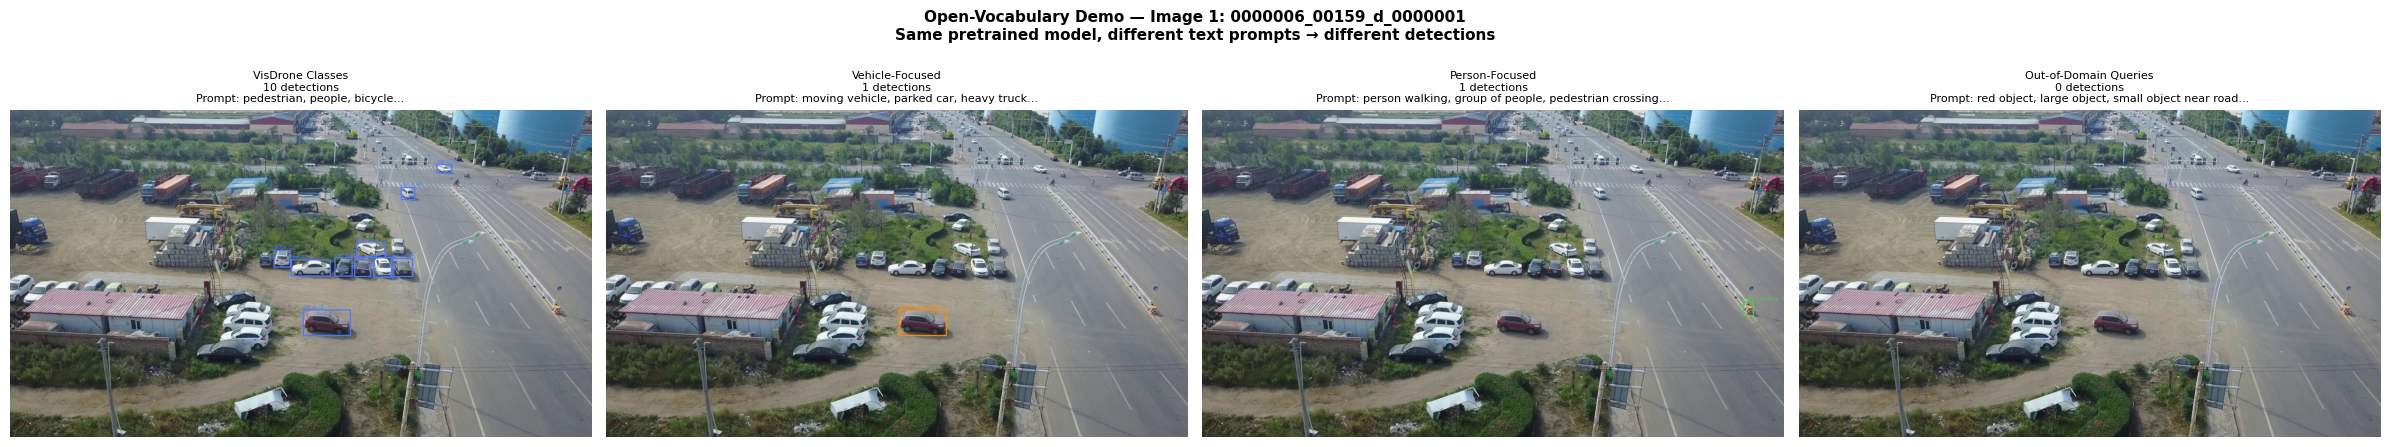

 NLP demo image 1 saved.


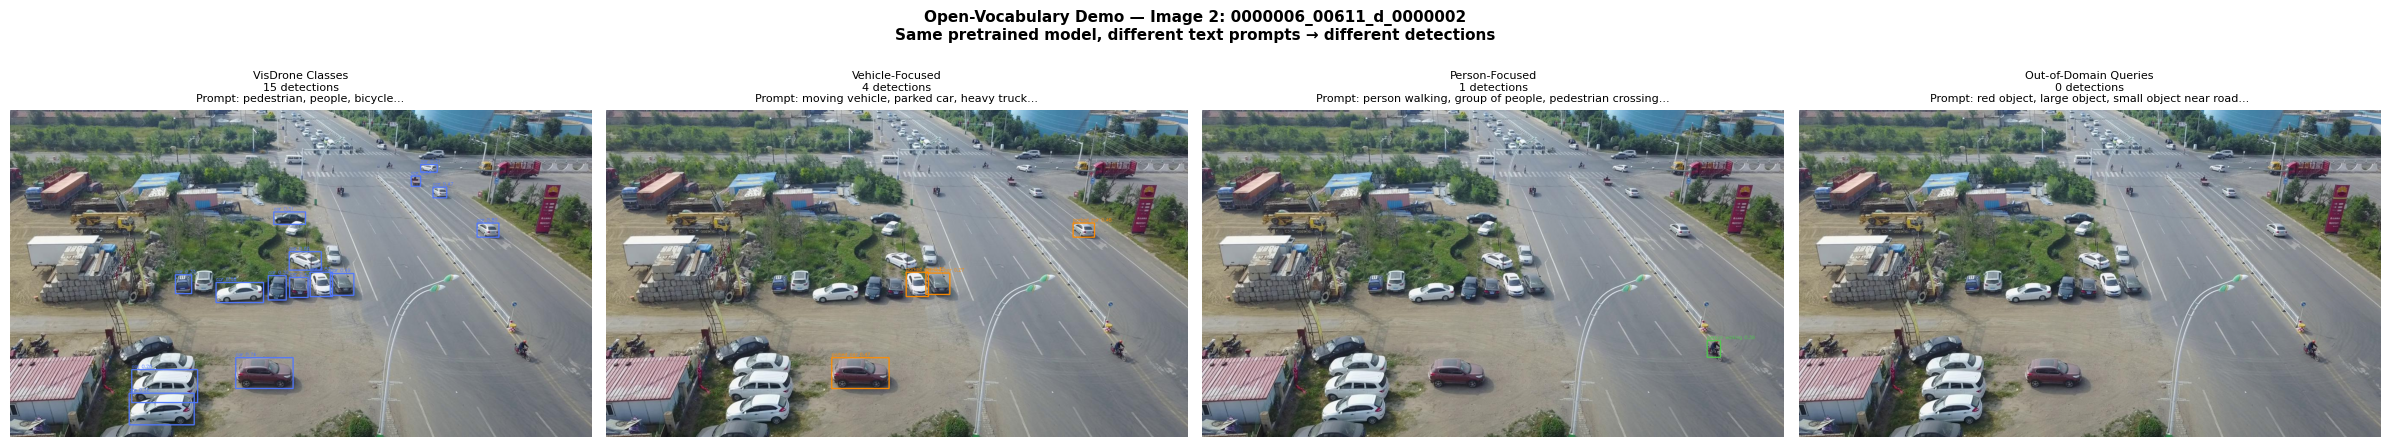

 NLP demo image 2 saved.


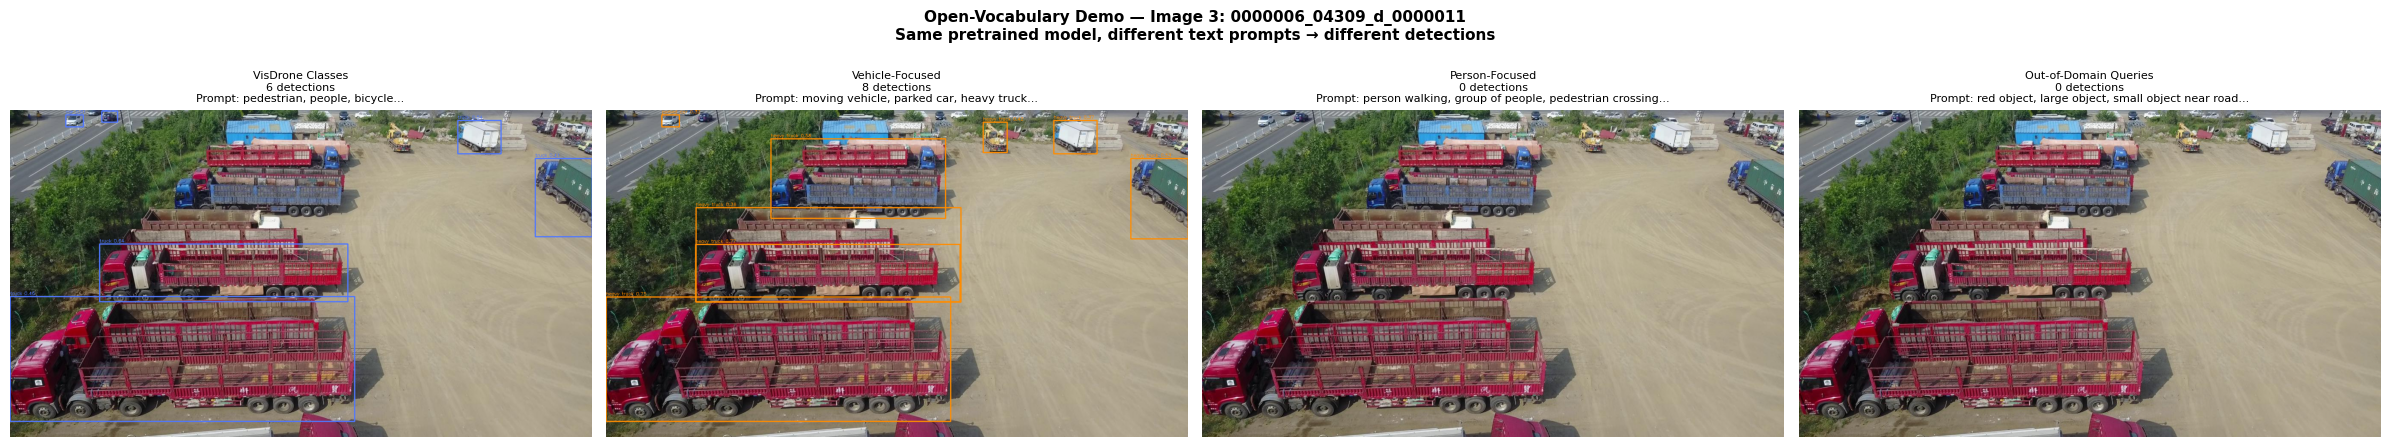

 NLP demo image 3 saved.

  NLP DEMO — DETECTION COUNTS ACROSS PROMPTS

  Query Set                  Img1  Img2  Img3    Avg
  ---------------------------------------------
  VisDrone Classes             10    15     6   10.3
  Vehicle-Focused               1     4     8    4.3
  Person-Focused                1     1     0    0.7
  Out-of-Domain Queries         0     0     0    0.0

  Detection count varies with prompt — proves semantic understanding.

 NLP demo complete.


In [21]:
# ─────────────────────────────────────────────────────────────
# GAP 1 — NATURAL LANGUAGE PROMPTING DEMO
# ─────────────────────────────────────────────────────────────
import torch
import gc
import copy
from ultralytics import YOLO

# Clean up
try:
    del nlp_model
    torch.cuda.empty_cache()
    gc.collect()
except:
    pass

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── Nuclear fix: deepcopy the entire model to strip inference mode ──
_tmp_model = YOLO(YW_CKPT_PATH)
_tmp_model.to(DEVICE)

# deepcopy creates entirely new tensors — none carry inference_mode flag
nlp_model = copy.deepcopy(_tmp_model)
del _tmp_model
torch.cuda.empty_cache()
gc.collect()

print("Model loaded and cloned ")

# ── Define query sets ─────────────────────────────────────────
QUERY_SETS = [
    {
        "name"   : "VisDrone Classes",
        "queries": ["pedestrian", "people", "bicycle", "car", "van",
                    "truck", "tricycle", "awning-tricycle", "bus",
                    "motor", "others"],
        "color"  : (80, 120, 255),
    },
    {
        "name"   : "Vehicle-Focused",
        "queries": ["moving vehicle", "parked car", "heavy truck",
                    "public bus", "two-wheeler", "van"],
        "color"  : (255, 140, 0),
    },
    {
        "name"   : "Person-Focused",
        "queries": ["person walking", "group of people",
                    "pedestrian crossing", "crowd"],
        "color"  : (80, 200, 80),
    },
    {
        "name"   : "Out-of-Domain Queries",
        "queries": ["red object", "large object",
                    "small object near road", "object in motion"],
        "color"  : (220, 60, 60),
    },
]

# ── Select 3 sample images ────────────────────────────────────
with open(STRESS_JSON) as f:
    stress_items = json.load(f)

sample_paths = []
for item in stress_items[:50]:
    p = item["image_path"]
    local_p = os.path.join(LOCAL_VAL_IMG, os.path.basename(p))
    if os.path.exists(local_p):
        sample_paths.append(local_p)
    elif os.path.exists(p):
        sample_paths.append(p)
    if len(sample_paths) == 3:
        break

print(f"Selected {len(sample_paths)} sample images")

# ── Draw helper ───────────────────────────────────────────────
def draw_detections(img_rgb, results, color, class_names):
    canvas = img_rgb.copy()
    n = 0
    if results and results[0].boxes is not None:
        for box in results[0].boxes:
            cls_id = int(box.cls.item())
            conf   = float(box.conf.item())
            x1,y1,x2,y2 = [int(v) for v in box.xyxy[0].tolist()]
            cv2.rectangle(canvas, (x1,y1), (x2,y2), color, 2)
            label = f"{class_names[cls_id] if cls_id < len(class_names) else cls_id} {conf:.2f}"
            cv2.putText(canvas, label, (x1, max(0,y1-4)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)
            n += 1
    return canvas, n

# ── Run demo ──────────────────────────────────────────────────
for img_idx, img_path in enumerate(sample_paths):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, len(QUERY_SETS), figsize=(6*len(QUERY_SETS), 5))

    for ax, qset in zip(axes, QUERY_SETS):
        nlp_model.set_classes(qset["queries"])
        results = nlp_model.predict(img_rgb, verbose=False, conf=0.25)
        canvas, n_det = draw_detections(
            img_rgb, results, qset["color"], qset["queries"]
        )
        ax.imshow(canvas)
        ax.set_title(f"{qset['name']}\n{n_det} detections\n"
                     f"Prompt: {', '.join(qset['queries'][:3])}...",
                     fontsize=8)
        ax.axis("off")

    img_name = Path(img_path).stem
    plt.suptitle(
        f"Open-Vocabulary Demo — Image {img_idx+1}: {img_name}\n"
        f"Same pretrained model, different text prompts → different detections",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    save_path = f"{STAGE_VIZ}/nlp_demo_image{img_idx+1}.png"
    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f" NLP demo image {img_idx+1} saved.")

# ── Quantitative table ────────────────────────────────────────
print("\n" + "="*55)
print("  NLP DEMO — DETECTION COUNTS ACROSS PROMPTS")
print("="*55)
print(f"\n  {'Query Set':<25} {'Img1':>5} {'Img2':>5} {'Img3':>5} {'Avg':>6}")
print(f"  {'-'*45}")

nlp_counts = {}
for qset in QUERY_SETS:
    nlp_model.set_classes(qset["queries"])
    counts = []
    for img_path in sample_paths:
        img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        results = nlp_model.predict(img_rgb, verbose=False, conf=0.25)
        n = len(results[0].boxes) if results and results[0].boxes else 0
        counts.append(n)
    avg = np.mean(counts)
    nlp_counts[qset["name"]] = counts
    print(f"  {qset['name']:<25} "
          f"{counts[0]:>5} {counts[1]:>5} {counts[2]:>5} {avg:>6.1f}")

print()
print("  Detection count varies with prompt — proves semantic understanding.")

with open(f"{STAGE_METRICS}/nlp_demo_counts.json", "w") as f:
    json.dump(nlp_counts, f, indent=2)

del nlp_model
torch.cuda.empty_cache()
gc.collect()
print("\n NLP demo complete.")

In [22]:
# ─────────────────────────────────────────────────────────────
# CELL 5: Save all outputs to Drive
# ─────────────────────────────────────────────────────────────
import subprocess

print("Copying all outputs to Drive...")
TAR_PATH = "/content/staging/extended_eval_outputs.tar.gz"

subprocess.run(f"tar -czf '{TAR_PATH}' -C '{STAGE}' .",
               shell=True, check=True)
subprocess.run(f"cp '{TAR_PATH}' '{OUTPUT_DIR}/' && sync",
               shell=True, check=True)
subprocess.run(
    f"tar -xzf '{OUTPUT_DIR}/extended_eval_outputs.tar.gz' "
    f"-C '{OUTPUT_DIR}'",
    shell=True, check=True
)
subprocess.run(
    f"rm '{OUTPUT_DIR}/extended_eval_outputs.tar.gz' && sync",
    shell=True, check=True
)
print("Outputs extracted to Drive.")

print("\nVerifying on Drive:")
expected = [
    (os.path.join(METRICS_DIR, "ablation_results.json"),  "ablation_results.json"),
    (os.path.join(METRICS_DIR, "extended_metrics.json"),  "extended_metrics.json"),
    (os.path.join(VIZ_DIR, "extended_eval", "ablation_study.png"), "ablation_study.png"),
    (os.path.join(VIZ_DIR, "extended_eval", "extended_metrics.png"), "extended_metrics.png"),
    (os.path.join(VIZ_DIR, "extended_eval", "nlp_demo_image1.png"), "nlp_demo_image1.png"),
    (os.path.join(VIZ_DIR, "extended_eval", "nlp_demo_image2.png"), "nlp_demo_image2.png"),
    (os.path.join(VIZ_DIR, "extended_eval", "nlp_demo_image3.png"), "nlp_demo_image3.png"),
]
all_ok = True
for path, label in expected:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    print(f"  {'' if exists else ''} {label} ({size:.1f} KB)")
    if not exists:
        all_ok = False

if all_ok:
    print("\n All outputs confirmed. Notebook 06 complete.")
else:
    print("\n Missing files — re-run relevant cells.")

Copying all outputs to Drive...
Outputs extracted to Drive.

Verifying on Drive:
   ablation_results.json (1.2 KB)
   extended_metrics.json (0.8 KB)
   ablation_study.png (98.5 KB)
   extended_metrics.png (145.9 KB)
   nlp_demo_image1.png (681.9 KB)
   nlp_demo_image2.png (695.0 KB)
   nlp_demo_image3.png (711.0 KB)

 All outputs confirmed. Notebook 06 complete.
